# 04 — Декомпозиция MLP vs Attention

Какой компонент архитектуры несёт иерархическую семантику — MLP или Attention?

Из архитектуры Pythia / GPT-NeoX:
```
resid_mid  = resid_pre + attn_out   (hook_attn_out)
resid_post = resid_mid + mlp_out    (hook_mlp_out)
```

RSA вычисляется **раздельно** для `attn_out` и `mlp_out` на каждом блоке.

**Задача 1:** Профиль RSA по слоям (финальный чекпоинт, обе модели)     
**Задача 2:** Динамика MLP/Attn по чекпоинтам (опционально)

**Статистика:**
- Тест перестановок (1000) для каждого компонента
- Парный тест перестановок для разности ρ_mlp − ρ_attn
- Wilcoxon signed-rank: MLP > Attn по всем слоям

**Требует:** `outputs/dataset.json` 

## Импорты и настройка

In [1]:
import argparse
import gc
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
from scipy.stats import spearmanr, wilcoxon
from transformer_lens import HookedTransformer

os.makedirs("outputs", exist_ok=True)

DATASET   = "outputs/dataset.json"
DEVICE    = "cpu"
RESUME    = True
RUN_CHECKPOINTS = True  # True = запустить также задачу 2 (медленно)

print(f"DEVICE={DEVICE}, RUN_CHECKPOINTS={RUN_CHECKPOINTS}")

/Users/ajratislamow/Desktop/deeplom/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE=cpu, RUN_CHECKPOINTS=True


## Вспомогательные функции

In [2]:
def load_dataset(path: str = "outputs/dataset.json"):
    with open(path) as f:
        records = json.load(f)
    words  = [r["word"]     for r in records]
    levels = [r["level"]    for r in records]
    cats   = [r["category"] for r in records]
    return words, levels, cats


def make_prompt(word: str) -> str:
    return f"The word '{word}' means"


def get_word_token_idx(model, prompt: str, word: str) -> int:
    tokens  = model.to_tokens(prompt)[0]
    raw     = [model.to_string(t.unsqueeze(0)) for t in tokens]
    tok_str = [s[0] if isinstance(s, list) else s for s in raw]
    clean   = word.lower().replace(" ", "").replace("_", "")
    for end in range(1, len(tok_str)):
        chunk = "".join(tok_str[1:end+1]).lower().replace(" ","").replace("'","").replace("_","")
        if clean in chunk:
            return end
    return len(tok_str) - 2

In [3]:
def whiten_pca(X: np.ndarray, k: int = 5) -> np.ndarray:
    X = X - X.mean(axis=0, keepdims=True)
    k = min(k, X.shape[0] - 1, X.shape[1])
    U, _, _ = np.linalg.svd(X, full_matrices=False)
    return U[:, :k] * np.sqrt(X.shape[0])


def cosine_sim_matrix(X: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-8
    Xn    = X / norms
    return Xn @ Xn.T


def rsa_score(X: np.ndarray, gt_flat: np.ndarray) -> float:
    if np.allclose(X, 0):
        return float("nan")
    try:
        W = whiten_pca(X, k=5)
    except np.linalg.LinAlgError:
        return float("nan")
    sim  = cosine_sim_matrix(W)
    flat = sim[np.triu_indices(len(X), k=1)]
    res  = spearmanr(flat, gt_flat)
    rho  = getattr(res, "statistic", None) or getattr(res, "correlation")
    return float(rho)


def permutation_test_rsa(X: np.ndarray, gt_flat: np.ndarray,
                          n_perm: int = 1000, rng=None) -> tuple:
    """Тест перестановок. Возвращает (observed_rho, p_value)."""
    if rng is None:
        rng = np.random.default_rng(42)
    if np.allclose(X, 0):
        return float("nan"), float("nan")
    n_words  = len(X)
    obs_rho  = rsa_score(X, gt_flat)
    null_rho = np.array([rsa_score(X[rng.permutation(n_words)], gt_flat)
                         for _ in range(n_perm)])
    p_value  = float(np.mean(null_rho >= obs_rho))
    return obs_rho, p_value


def build_gt_flat(levels, cats):
    n  = len(levels)
    gt = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if cats[i] == cats[j]:
                gt[i, j] = 1.0 / (1.0 + abs(levels[i] - levels[j]))
    return gt[np.triu_indices(n, k=1)]

### Декомпозированное извлечение активаций

Извлекаем три потока для каждого слоя:
- `attn_out` — выход механизма attention (Δ_attn)
- `mlp_out` — выход MLP блока (Δ_mlp)
- `resid_post` — полный residual stream (baseline)

In [4]:
def extract_decomposed(model, words: list) -> dict:
    """
    Возвращает {
        'attn':  [n_layers, N, d_model],
        'mlp':   [n_layers, N, d_model],
        'resid': [n_layers+1, N, d_model],  # layer 0 = embedding
    }
    """
    n_layers = model.cfg.n_layers
    d_model  = model.cfg.d_model
    n        = len(words)

    attn  = np.zeros((n_layers, n, d_model), dtype=np.float32)
    mlp   = np.zeros((n_layers, n, d_model), dtype=np.float32)
    resid = np.zeros((n_layers + 1, n, d_model), dtype=np.float32)

    for wi, word in enumerate(words):
        prompt = make_prompt(word)
        tokens = model.to_tokens(prompt)
        idx    = get_word_token_idx(model, prompt, word)

        with torch.no_grad():
            _, cache = model.run_with_cache(tokens)

        resid[0, wi] = cache["blocks.0.hook_resid_pre"][0, idx].cpu().numpy()
        for l in range(n_layers):
            attn[l, wi]    = cache[f"blocks.{l}.hook_attn_out"][0, idx].cpu().numpy()
            mlp[l, wi]     = cache[f"blocks.{l}.hook_mlp_out"][0, idx].cpu().numpy()
            resid[l+1, wi] = cache[f"blocks.{l}.hook_resid_post"][0, idx].cpu().numpy()

    return {"attn": attn, "mlp": mlp, "resid": resid}

## Загрузка датасета

In [5]:
words, levels, cats = load_dataset(DATASET)
gt_flat = build_gt_flat(levels, cats)
print(f"Датасет: {len(words)} слов, {len(gt_flat)} пар")

Датасет: 123 слов, 7503 пар


## Задача 1: Профиль по слоям

Для каждого слоя: RSA(attn_out), RSA(mlp_out), RSA(resid_post) + тесты перестановок.

**Парный permutation test:** одинаковые перестановки для attn и mlp → корректный нуль
для разности ρ_mlp − ρ_attn.

**Wilcoxon signed-rank:** сравнивает (ρ_mlp[l], ρ_attn[l]) по всем слоям.
Непараметрический аналог парного t-теста, не требует нормальности разностей.

In [6]:
def task_layer_profile(model, words, levels, cats, model_name, out_dir):
    """Вычисляет профиль RSA по слоям для attn/mlp/resid."""
    n_layers = model.cfg.n_layers
    gt_flat  = build_gt_flat(levels, cats)
    n        = len(words)

    print(f"  Извлечение активаций ({n} слов × {n_layers} слоёв) …")
    streams = extract_decomposed(model, words)

    rng    = np.random.default_rng(42)
    n_perm = 1000
    scores = {"attn": [], "mlp": [], "resid": []}
    pvals  = {"attn": [], "mlp": [], "diff":  []}

    print(f"  Тест перестановок ({n_perm} × {n_layers} слоёв) …")

    for l in range(n_layers + 1):
        scores["resid"].append(rsa_score(streams["resid"][l], gt_flat))

    for l in range(n_layers):
        X_attn = streams["attn"][l]
        X_mlp  = streams["mlp"][l]
        obs_a   = rsa_score(X_attn, gt_flat)
        obs_m   = rsa_score(X_mlp,  gt_flat)
        obs_diff = obs_m - obs_a

        null_a, null_m, null_diff = np.empty(n_perm), np.empty(n_perm), np.empty(n_perm)
        for i in range(n_perm):
            perm         = rng.permutation(n)
            null_a[i]    = rsa_score(X_attn[perm], gt_flat)
            null_m[i]    = rsa_score(X_mlp[perm],  gt_flat)
            null_diff[i] = null_m[i] - null_a[i]

        scores["attn"].append(obs_a)
        scores["mlp"].append(obs_m)
        pvals["attn"].append(float(np.mean(null_a    >= obs_a)))
        pvals["mlp"].append( float(np.mean(null_m    >= obs_m)))
        pvals["diff"].append(float(np.mean(null_diff >= obs_diff)))

    # ── График ───────────────────────────────────────────────────────────
    fig, (ax, ax_p) = plt.subplots(2, 1, figsize=(10, 7),
                                    gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
    xs_resid = list(range(n_layers + 1))
    xs_block  = list(range(1, n_layers + 1))

    ax.plot(xs_resid, scores["resid"], "o-",
            color="#78909C", linewidth=1.8, label="Остаточный поток", alpha=0.7)
    ax.plot(xs_block, scores["attn"], "s-",
            color="#1976D2", linewidth=2.2, label="Δ Attention (attn_out)")
    ax.plot(xs_block, scores["mlp"],  "^-",
            color="#E53935", linewidth=2.2, label="Δ MLP (mlp_out)")
    ax.axhline(0, color="grey", linewidth=0.7, linestyle=":")
    ax.set_ylabel("Spearman ρ  (RSA vs иерархия WordNet)", fontsize=12)
    ax.set_title(f"MLP vs Attention — {model_name}\nФинальный чекпоинт  ({n} слов)",
                 fontweight="bold", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    p_min = [min(a, m) for a, m in zip(pvals["attn"], pvals["mlp"])]
    bar_colors = ["#43A047" if p < 0.05 else "#EF5350" for p in p_min]
    ax_p.bar(xs_block, [-np.log10(p + 1e-4) for p in p_min],
             color=bar_colors, alpha=0.85, width=0.6)
    ax_p.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1, label="p=0.05")
    ax_p.axhline(-np.log10(0.01), color="black", linestyle=":",  linewidth=1, label="p=0.01")
    ax_p.set_ylabel("-log₁₀(p)\n[min(attn,mlp)]", fontsize=9)
    ax_p.set_xlabel("Слой  (0 = эмбеддинг)", fontsize=12)
    ax_p.legend(fontsize=8, loc="upper left")
    ax_p.grid(True, alpha=0.2)

    slug = model_name.replace("pythia-", "")
    path = f"{out_dir}/decomp_layer_profile_{slug}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Сохранено → {path}")

    # ── Таблица результатов ──────────────────────────────────────────────
    def _sig(p):
        if np.isnan(p): return "n/a"
        return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."

    print(f"\n  {'Layer':<7} {'Attn ρ':>9} {'p':>7} {'MLP ρ':>9} {'p':>7} "
          f"{'MLP>Attn':>9} {'Resid ρ':>9}")
    print(f"  {'-'*66}")
    for l in range(n_layers):
        print(f"  L{l+1:<6} {scores['attn'][l]:>9.4f} {_sig(pvals['attn'][l]):>7} "
              f"{scores['mlp'][l]:>9.4f} {_sig(pvals['mlp'][l]):>7} "
              f"{_sig(pvals['diff'][l]):>9} {scores['resid'][l+1]:>9.4f}")

    # ── Wilcoxon MLP vs Attn ─────────────────────────────────────────────
    diffs = [m - a for m, a in zip(scores["mlp"], scores["attn"])]
    stat_w, pval_w = wilcoxon(diffs, alternative="greater")
    sig_w = "***" if pval_w < 0.001 else "**" if pval_w < 0.01 else \
            "*"   if pval_w < 0.05  else "n.s."
    n_mlp_higher = sum(d > 0 for d in diffs)
    mean_diff = float(np.mean(diffs))

    print(f"\n  ── Wilcoxon signed-rank: MLP > Attn по сети ──")
    print(f"  Слоёв MLP > Attn: {n_mlp_higher}/{n_layers}")
    print(f"  Средняя Δρ(MLP−Attn): {mean_diff:+.4f}")
    print(f"  Wilcoxon W={stat_w:.1f}  p={pval_w:.4f}  {sig_w}")

    return scores, pvals

## pythia-160m: профиль по слоям

Загрузка pythia-160m …


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model EleutherAI/pythia-160m into HookedTransformer

[Задача 1] Профиль по слоям — pythia-160m
  Извлечение активаций (123 слов × 12 слоёв) …
  Тест перестановок (1000 × 12 слоёв) …


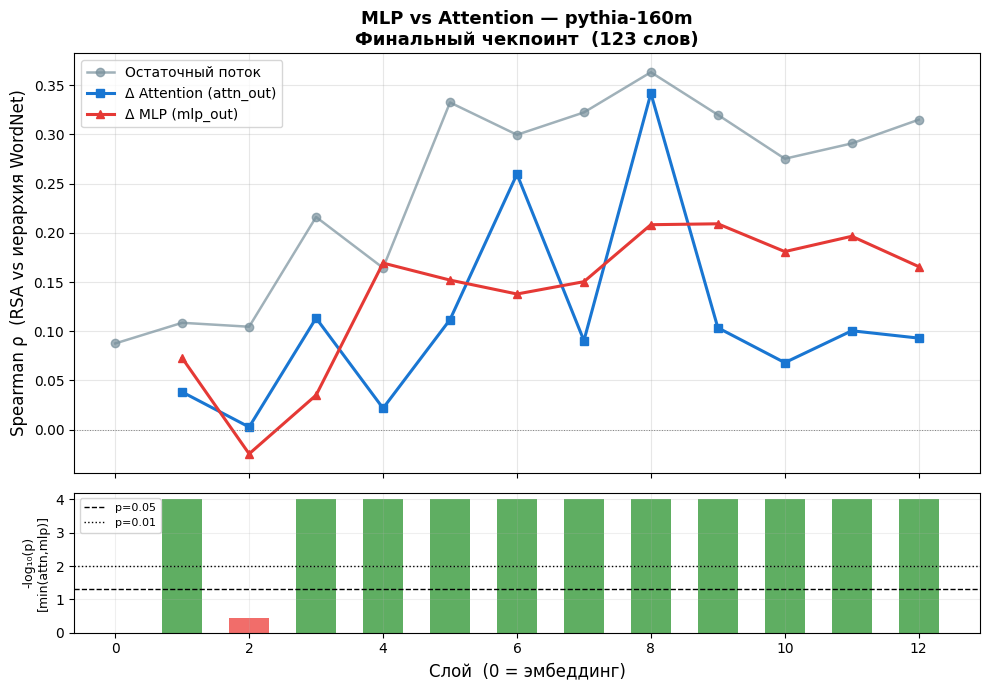

  Сохранено → outputs/decomp_layer_profile_160m.png

  Layer      Attn ρ       p     MLP ρ       p  MLP>Attn   Resid ρ
  ------------------------------------------------------------------
  L1         0.0382      **    0.0728     ***        **    0.1086
  L2         0.0026    n.s.   -0.0246    n.s.      n.s.    0.1046
  L3         0.1133     ***    0.0350       *      n.s.    0.2160
  L4         0.0217       *    0.1693     ***       ***    0.1643
  L5         0.1118     ***    0.1520     ***        **    0.3324
  L6         0.2596     ***    0.1378     ***      n.s.    0.2996
  L7         0.0904     ***    0.1503     ***       ***    0.3223
  L8         0.3417     ***    0.2082     ***      n.s.    0.3632
  L9         0.1035     ***    0.2091     ***       ***    0.3199
  L10        0.0681     ***    0.1809     ***       ***    0.2753
  L11        0.1005     ***    0.1965     ***       ***    0.2908
  L12        0.0930     ***    0.1656     ***       ***    0.3149

  ── Wilcoxon signe

9387

In [7]:
print("Загрузка pythia-160m …")
model_160m = HookedTransformer.from_pretrained(
    "EleutherAI/pythia-160m",
    center_unembed=True, center_writing_weights=True,
    fold_ln=True, device=DEVICE)
model_160m.eval()
n_layers_160m = model_160m.cfg.n_layers

print("\n[Задача 1] Профиль по слоям — pythia-160m")
scores_160m, pvals_160m = task_layer_profile(
    model_160m, words, levels, cats, "pythia-160m", "outputs")

# Сохраняем CSV
rows_160m = [
    {"layer":          l+1,
     "rsa_attn":       scores_160m["attn"][l],
     "rsa_mlp":        scores_160m["mlp"][l],
     "rsa_resid":      scores_160m["resid"][l+1],
     "p_attn":         pvals_160m["attn"][l],
     "p_mlp":          pvals_160m["mlp"][l],
     "p_mlp_gt_attn":  pvals_160m["diff"][l]}
    for l in range(n_layers_160m)
]
pd.DataFrame(rows_160m).to_csv("outputs/decomp_layer_profile_160m.csv", index=False)
print("  CSV → outputs/decomp_layer_profile_160m.csv")

del model_160m
gc.collect()

## pythia-1b: профиль по слоям

Загрузка pythia-1b …
Loaded pretrained model EleutherAI/pythia-1b into HookedTransformer

[Задача 1] Профиль по слоям — pythia-1b
  Извлечение активаций (123 слов × 16 слоёв) …
  Тест перестановок (1000 × 16 слоёв) …


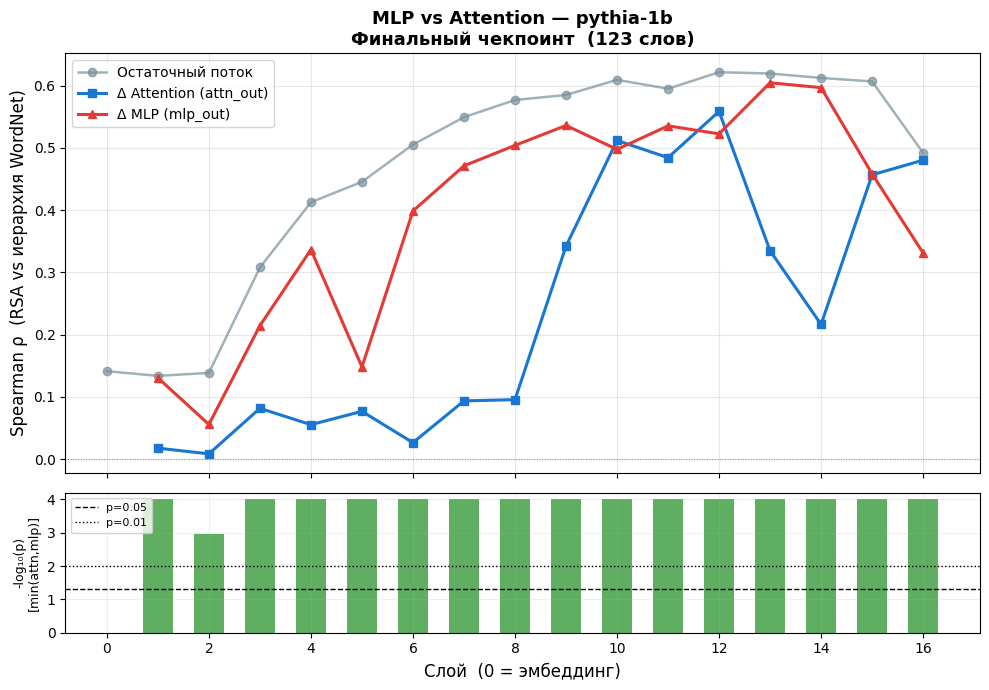

  Сохранено → outputs/decomp_layer_profile_1b.png

  Layer      Attn ρ       p     MLP ρ       p  MLP>Attn   Resid ρ
  ------------------------------------------------------------------
  L1         0.0175    n.s.    0.1305     ***       ***    0.1337
  L2         0.0083    n.s.    0.0556      **        **    0.1384
  L3         0.0814     ***    0.2144     ***       ***    0.3079
  L4         0.0552     ***    0.3366     ***       ***    0.4127
  L5         0.0766     ***    0.1481     ***       ***    0.4455
  L6         0.0263       *    0.3987     ***       ***    0.5054
  L7         0.0934     ***    0.4713     ***       ***    0.5495
  L8         0.0955     ***    0.5041     ***       ***    0.5771
  L9         0.3421     ***    0.5361     ***       ***    0.5851
  L10        0.5120     ***    0.4977     ***      n.s.    0.6095
  L11        0.4844     ***    0.5355     ***       ***    0.5952
  L12        0.5588     ***    0.5227     ***      n.s.    0.6217
  L13        0.3348   

9346

In [8]:
print("Загрузка pythia-1b …")
model_1b = HookedTransformer.from_pretrained(
    "EleutherAI/pythia-1b",
    center_unembed=True, center_writing_weights=True,
    fold_ln=True, device=DEVICE)
model_1b.eval()
n_layers_1b = model_1b.cfg.n_layers

print("\n[Задача 1] Профиль по слоям — pythia-1b")
scores_1b, pvals_1b = task_layer_profile(
    model_1b, words, levels, cats, "pythia-1b", "outputs")

rows_1b = [
    {"layer":          l+1,
     "rsa_attn":       scores_1b["attn"][l],
     "rsa_mlp":        scores_1b["mlp"][l],
     "rsa_resid":      scores_1b["resid"][l+1],
     "p_attn":         pvals_1b["attn"][l],
     "p_mlp":          pvals_1b["mlp"][l],
     "p_mlp_gt_attn":  pvals_1b["diff"][l]}
    for l in range(n_layers_1b)
]
pd.DataFrame(rows_1b).to_csv("outputs/decomp_layer_profile_1b.csv", index=False)
print("  CSV → outputs/decomp_layer_profile_1b.csv")

del model_1b
gc.collect()

## Сравнительный график L8: 160m vs 1b

Сравниваем RSA attn/mlp/resid на одном слое L8 для обеих моделей.

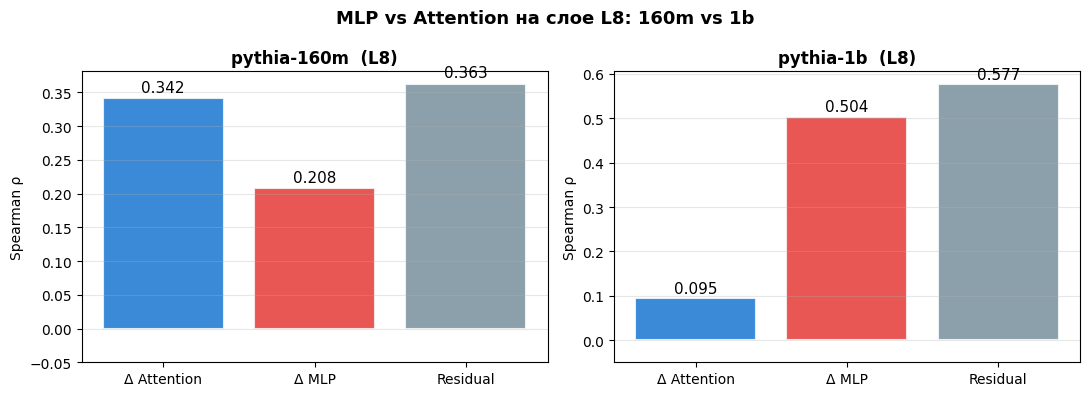

Сохранено → outputs/decomp_l8_comparison.png


In [9]:
L8 = 8  # сравниваемый слой (индекс в массиве: L8-1=7 для attn/mlp)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (scores, n_layers, model_name) in zip(
    axes,
    [(scores_160m, n_layers_160m, "pythia-160m"),
     (scores_1b,   n_layers_1b,   "pythia-1b")]
):
    if L8 - 1 >= len(scores["attn"]):
        ax.text(0.5, 0.5, f"L{L8} недоступен для {model_name}",
                ha="center", va="center", transform=ax.transAxes)
        continue

    bars = ax.bar(
        ["Δ Attention", "Δ MLP", "Residual"],
        [scores["attn"][L8-1], scores["mlp"][L8-1], scores["resid"][L8]],
        color=["#1976D2", "#E53935", "#78909C"],
        edgecolor="white", linewidth=1.5, alpha=0.85
    )
    for bar, val in zip(bars, [scores["attn"][L8-1], scores["mlp"][L8-1], scores["resid"][L8]]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=11)
    ax.set_ylabel("Spearman ρ")
    ax.set_title(f"{model_name}  (L{L8})", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim(bottom=min(0, min(scores["attn"][L8-1], scores["mlp"][L8-1])) - 0.05)

fig.suptitle(f"MLP vs Attention на слое L{L8}: 160m vs 1b", fontweight="bold", fontsize=13)
fig.tight_layout()
fig.savefig("outputs/decomp_l8_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Сохранено → outputs/decomp_l8_comparison.png")

## Задача 2: Динамика MLP/Attn по чекпоинтам (опционально)

Отслеживаем RSA(attn), RSA(mlp), RSA(resid) на фиксированном слое L8
по 30 чекпоинтам обучения.

⚠ Устанавливайте `RUN_CHECKPOINTS = True` в параметрах — это медленный прогон
(~30 × загрузка модели).

In [13]:
FAST_STEPS = [
    0, 1, 2, 4, 8, 16, 32, 64, 128, 256, 512,
    1000, 2000, 3000, 5000, 7000, 10000, 15000, 20000,
    30000, 40000, 50000, 60000, 70000, 80000, 90000,
    100000, 110000, 120000, 130000, 143000,
]


def task_checkpoint_dynamics(words, levels, cats, model_name, target_layer,
                              device, out_dir, resume):
    """Динамика attn/mlp/resid RSA по чекпоинтам на одном слое."""
    gt_flat  = build_gt_flat(levels, cats)
    slug     = model_name.replace("pythia-", "")
    out_csv  = f"{out_dir}/decomp_checkpoint_{slug}.csv"

    if resume and os.path.exists(out_csv):
        done_df    = pd.read_csv(out_csv)
        done_steps = set(done_df["step"].tolist())
        rows       = done_df.to_dict("records")
        print(f"  Resume: {len(done_steps)} шагов уже вычислено.")
    else:
        done_steps = set()
        rows       = []

    total = len(FAST_STEPS)
    for i, step in enumerate(FAST_STEPS):
        if step in done_steps:
            continue
        print(f"  [{i+1}/{total}]  step {step:>7,} … ", end="", flush=True)
        try:
            model = HookedTransformer.from_pretrained(
                f"EleutherAI/{model_name}",
                revision=f"step{step}",
                center_unembed=True, center_writing_weights=True,
                fold_ln=True, device=device)
            model.eval()

            streams = extract_decomposed(model, words)
            l = target_layer - 1

            rho_attn  = rsa_score(streams["attn"][l],           gt_flat)
            rho_mlp   = rsa_score(streams["mlp"][l],            gt_flat)
            rho_resid = rsa_score(streams["resid"][target_layer], gt_flat)

            rows.append({"step": step,
                         "rsa_attn":  rho_attn,
                         "rsa_mlp":   rho_mlp,
                         "rsa_resid": rho_resid})
            print(f"attn={rho_attn:.3f}  mlp={rho_mlp:.3f}  resid={rho_resid:.3f}")
            del model, streams
            gc.collect()
        except Exception as e:
            print(f"ERROR: {e}")
            rows.append({"step": step,
                         "rsa_attn": float("nan"),
                         "rsa_mlp":  float("nan"),
                         "rsa_resid": float("nan")})

        pd.DataFrame(rows).sort_values("step").to_csv(out_csv, index=False)

    df = pd.read_csv(out_csv).sort_values("step").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df["step"], df["rsa_resid"], "-",
            color="#78909C", linewidth=1.8, alpha=0.6, label="Остаточный поток")
    ax.plot(df["step"], df["rsa_attn"],  "s-",
            color="#1976D2", linewidth=2.2, label="Δ Attention")
    ax.plot(df["step"], df["rsa_mlp"],   "^-",
            color="#E53935", linewidth=2.2, label="Δ MLP")
    ax.axvline(x=1000, color="grey", linestyle="--", linewidth=1.1,
               label="Шаг 1 000 (фазовый переход)")
    ax.set_xscale("symlog", linthresh=512)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{int(x):,}" if x >= 1 else "0"))
    ax.set_xlabel("Шаг обучения  (symlog шкала)", fontsize=12)
    ax.set_ylabel("Spearman ρ", fontsize=12)
    ax.set_title(f"MLP vs Attention динамика — {model_name}  (слой {target_layer})\n"
                 f"RSA по {len(df)} чекпоинтам",
                 fontweight="bold", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    path = f"{out_dir}/decomp_checkpoint_{slug}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"\n  Сохранено → {path}")
    print(f"  Сохранено → {out_csv}")


[Задача 2] Динамика по чекпоинтам — pythia-160m  (layer 8)
  Resume: 31 шагов уже вычислено.


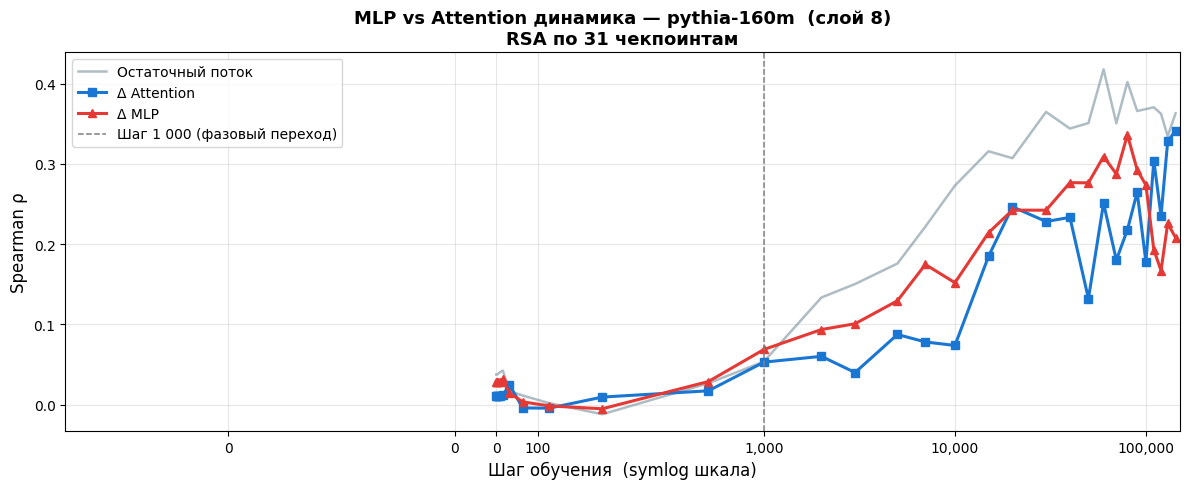


  Сохранено → outputs/decomp_checkpoint_160m.png
  Сохранено → outputs/decomp_checkpoint_160m.csv

[Задача 2] Динамика по чекпоинтам — pythia-1b  (layer 8)
  Resume: 31 шагов уже вычислено.


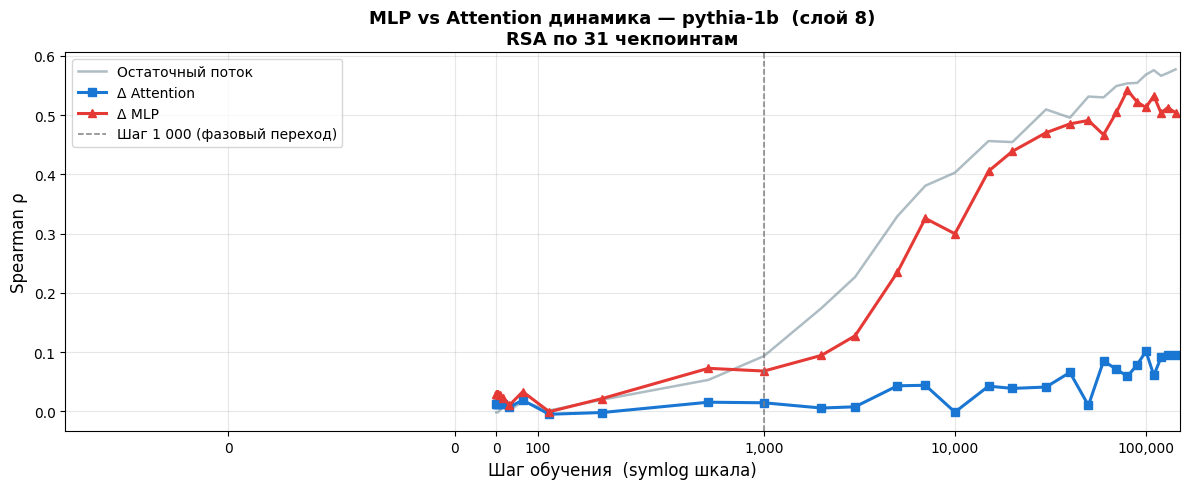


  Сохранено → outputs/decomp_checkpoint_1b.png
  Сохранено → outputs/decomp_checkpoint_1b.csv


In [14]:
if RUN_CHECKPOINTS:
    TARGET_LAYER = 8
    print(f"\n[Задача 2] Динамика по чекпоинтам — pythia-160m  (layer {TARGET_LAYER})")
    task_checkpoint_dynamics(words, levels, cats, "pythia-160m",
                              TARGET_LAYER, DEVICE, "outputs", RESUME)

    print(f"\n[Задача 2] Динамика по чекпоинтам — pythia-1b  (layer {TARGET_LAYER})")
    task_checkpoint_dynamics(words, levels, cats, "pythia-1b",
                              TARGET_LAYER, DEVICE, "outputs", RESUME)
else:
    print("RUN_CHECKPOINTS=False — задача 2 пропущена.")
    print("Установите RUN_CHECKPOINTS = True для запуска.")

## Сравнительный график динамики (если задача 2 выполнена)

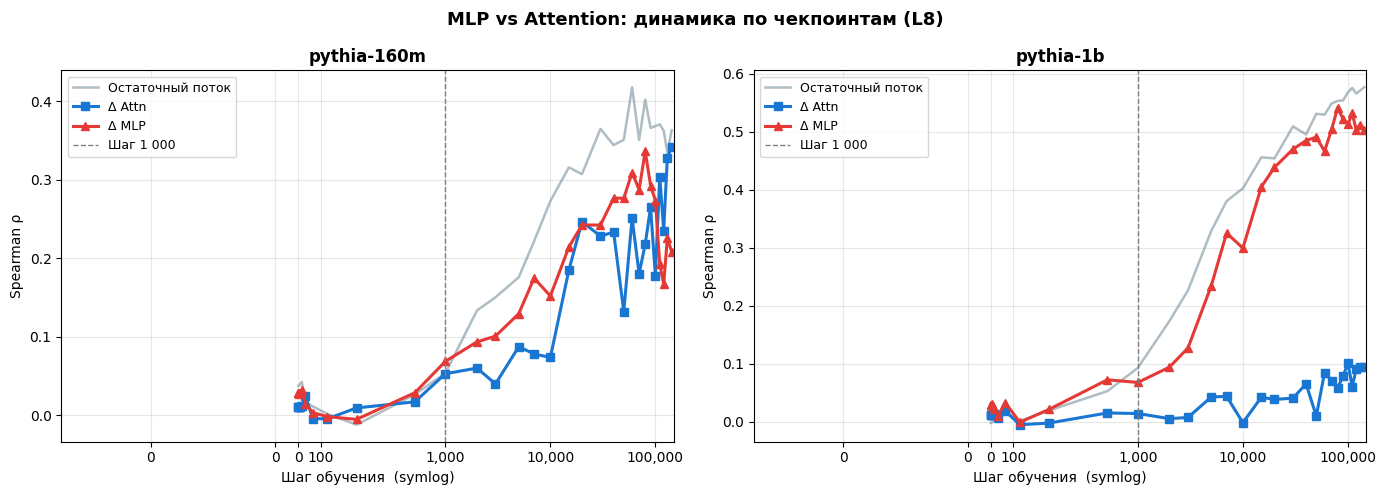

Сохранено → outputs/decomp_checkpoint_comparison.png


In [15]:
csv_160m_ck = "outputs/decomp_checkpoint_160m.csv"
csv_1b_ck   = "outputs/decomp_checkpoint_1b.csv"

if os.path.exists(csv_160m_ck) and os.path.exists(csv_1b_ck):
    df_160m_ck = pd.read_csv(csv_160m_ck)
    df_1b_ck   = pd.read_csv(csv_1b_ck)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, df, model_name in zip(
        axes,
        [df_160m_ck, df_1b_ck],
        ["pythia-160m", "pythia-1b"]
    ):
        ax.plot(df["step"], df["rsa_resid"], "-",
                color="#78909C", linewidth=1.8, alpha=0.6, label="Остаточный поток")
        ax.plot(df["step"], df["rsa_attn"],  "s-",
                color="#1976D2", linewidth=2.2, label="Δ Attn")
        ax.plot(df["step"], df["rsa_mlp"],   "^-",
                color="#E53935", linewidth=2.2, label="Δ MLP")
        ax.axvline(x=1000, color="grey", linestyle="--", linewidth=1,
                   label="Шаг 1 000")
        ax.set_xscale("symlog", linthresh=512)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x):,}" if x >= 1 else "0"))
        ax.set_xlabel("Шаг обучения  (symlog)")
        ax.set_ylabel("Spearman ρ")
        ax.set_title(model_name, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle("MLP vs Attention: динамика по чекпоинтам (L8)",
                 fontweight="bold", fontsize=13)
    fig.tight_layout()
    fig.savefig("outputs/decomp_checkpoint_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Сохранено → outputs/decomp_checkpoint_comparison.png")
else:
    print("CSV файлы чекпоинтов не найдены — запустите задачу 2 сначала.")